In [1]:
import os
import pynwb
import h5py
from tqdm import tqdm
import pandas as pd
from pathlib import Path
import numpy as np
import seaborn as sns
import pywt
import matplotlib
import graph
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import gridspec

from scipy import signal
from scipy.fftpack import next_fast_len
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter1d
from scipy.signal import filtfilt, hilbert, remez, sosfiltfilt, butter

import load_data
import LFP

In [2]:
class LFPDataset:
    
    def __init__(self, h5_path):
        self.f = h5py.File(h5_path, 'r')
        self.band_sig = self.f['band_sig']
        self.power = self.f['power']
        self.phase = self.f['phase']

    def get_trace(self, time):
        return self.band_sig[time, :].T, self.power[time, :].T, self.phase[time, :].T

    def get_band_sig(self, time):
        if len(time)==0:
            return self.band_sig[:]
        else:
            return self.band_sig[time, :]

    def get_power(self, time):
        if len(time)==0:
            return self.power[:]
        else:
            return self.power[time, :]

    def get_phase(self, time):
        if len(time)==0:
            return self.phase[:]
        else:
            return self.phase[time, :]

    def close(self):
        self.f.close()

In [3]:
def epoch_aligned_band(date,df,window,ds):


    timestamps, lfpData = load_data.load_LFP(date)
    
    num_ch = ds.band_sig.shape[1]
    aligned_lfp = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    aligned_signal = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    aligned_power = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    aligned_phase = np.zeros((len(df),num_ch,window[1]-window[0])).astype(np.float32)
    
    for ii in range(len(df)):

        on = df.iloc[ii].t_on.astype(float)
        idx = (timestamps>on+window[0]) & (timestamps<on+window[1])
        aligned_lfp[ii,:,:] = lfpData[idx,:].T.astype(np.float32)
        aligned_signal[ii,:,:], aligned_power[ii,:,:], aligned_phase[ii,:,:] = ds.get_trace(idx)

    ds.close()
    
    return {'LFP': aligned_lfp,
            'band': aligned_signal, 
            'power': aligned_power, 
            'phase': aligned_phase}

In [4]:
def value_band_power(date,choice_df,band,
                    query = 'trialerror==0'):

    if band=='theta':
        ds = LFPDataset("D:/Theta/Session_%s_theta.h5" % date)

    if band=='alpha':
        ds = LFPDataset("D:/Alpha/Session_%s_8_30.h5" % date)
    

    aligned_band = epoch_aligned_band(date,choice_df,[0,500],ds)
    power = aligned_band['power'].mean(axis=2)   # (1499, 192)
    
    # ---- make dataframe ----
    df = pd.DataFrame(power)
    df['value'] = choice_df['value'].values
    df['trial'] = np.arange(len(df))
    
    # ---- reshape to long format ----
    channel_power = df.melt(
        id_vars=['trial', 'value'],
        var_name='channel',
        value_name='power'
    )
    
    # optional: make channel integer
    channel_power['channel'] = channel_power['channel'].astype(int)

    return channel_power

In [ ]:
# get coherence

In [9]:
# load data
date = '031723'
query = 'trialerror==0'
nwbfile = load_data.load_nwbfile('Bart',date) 
choice_df = nwbfile.intervals['action_on'].to_dataframe().query(query)
choice_df['value'] = np.maximum(0,3-choice_df['graph_distance'].values)
alpha_ds = LFPDataset("D:/Alpha/Session_%s_8_30.h5" % date)

In [10]:
aligned_band = epoch_aligned_band(date,choice_df,[-250,750],alpha_ds)

In [40]:
theta_long = value_band_power(date,choice_df,'theta')

<Axes: xlabel='value', ylabel='theta_power'>

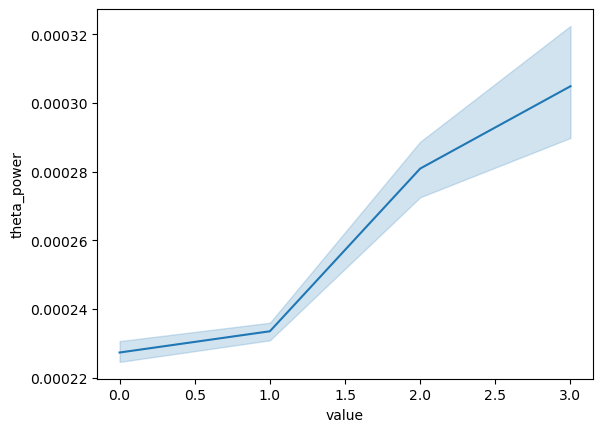

In [41]:
plt.close('all')
sns.lineplot(data=theta_long.query('channel<96'), x='value',y='theta_power')

<Axes: xlabel='value', ylabel='theta_power'>

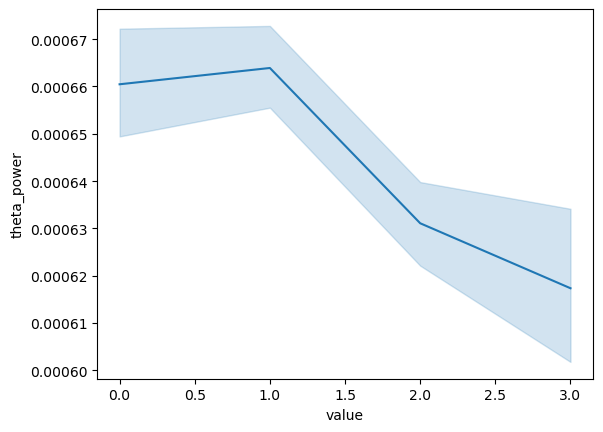

In [42]:
plt.close('all')
sns.lineplot(data=theta_long.query('channel>96'), x='value',y='theta_power')

In [43]:
alpha_long = value_band_power(date,choice_df,'alpha')

<Axes: xlabel='value', ylabel='theta_power'>

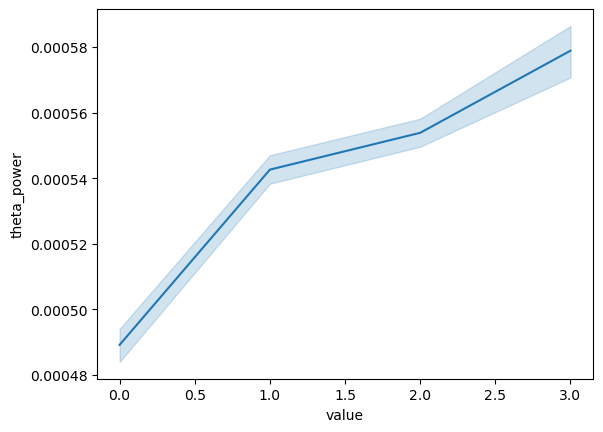

In [45]:
plt.close('all')
sns.lineplot(data=alpha_long.query('channel < 96'),
             x='value',
             y='theta_power')

<Axes: xlabel='value', ylabel='alpha_power'>

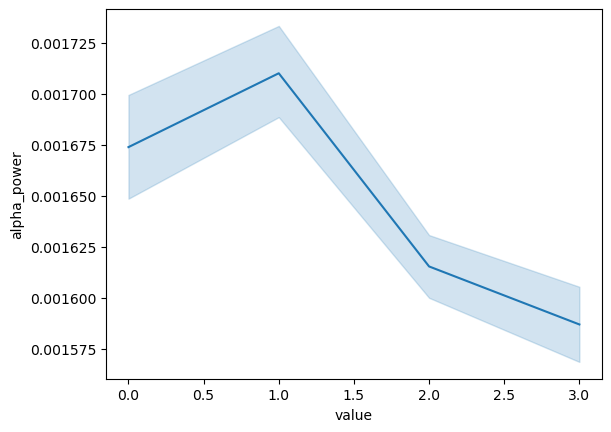

In [36]:
plt.close('all')
sns.lineplot(data=alpha_long.query('channel > 96'),
             x='value',
             y='alpha_power')